# Preimage Approximation

Given a trained classifier $f: \mathbb{R}^d \to \mathbb{R}^k$, we use
[auto_LiRPA](https://github.com/Certified-Robustness/auto_LiRPA) to obtain
linear relaxations of each class region.  The relaxation bounds define **inner**
polytopes in input space that approximate the true preimage of every class.

### Key validity constraint

LiRPA's backward-mode A-matrices are **local** certificates.  For sample $x_i$
with perturbation radius $\varepsilon$, the bound
$$\ell_j(x) = A^\ell_j\, x + b^\ell_j \;\le\; g_j(x)$$
holds **only** for $x \in \mathcal{B}(x_i,\,\varepsilon)$.  
Each polytope must therefore be intersected with that ball (approximated here
as an $\ell_\infty$ box or a regular polygon), **not** with a global bounding box.

Pipeline:
1. Load data & model
2. Wrap model with one-vs-all constraint layer
3. Run LiRPA → extract per-sample $A, b$ blocks
4. Clip each polytope to the $\varepsilon$-ball around its centre
5. Visualise individual polytopes per class
6. Compute per-class **union** (Shapely)
7. Refine unions by subtracting pairwise overlaps (priority-based)
8. Diagnostic: pairwise overlap heatmap


## 1 – Imports & seed

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from scipy.spatial import HalfspaceIntersection, ConvexHull
from shapely.geometry import Polygon
from shapely.ops import unary_union

from auto_LiRPA import BoundedModule, BoundedTensor, PerturbationLpNorm

from src.network  import SimpleClassifier
from src.preimage import WrappedModel

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2 – Dataset

In [2]:
test_dataset = torch.load('test_spiral.pt', weights_only=True)

label_dataset = {}
for img, label in test_dataset:
    label_dataset.setdefault(label.item(), []).append(img)
label_dataset = {k: torch.stack(v) for k, v in label_dataset.items()}

n_classes = len(label_dataset)
print(f'{n_classes} classes | total samples: {sum(v.size(0) for v in label_dataset.values())}')

10 classes | total samples: 400


## 3 – Model

In [3]:
model = SimpleClassifier().to(device)
model.load_state_dict(torch.load('mnist_simple_classifier.pth', map_location=device,
                                  weights_only=True))
model.eval()
print(model)

SimpleClassifier(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=10, bias=True)
  )
)


## 4 – LiRPA bound propagation

### Constraint layer recap

`WrappedModel` appends a fixed linear layer that computes
$g_i = z_y - z_i$ for every $i \ne y$.
Label $y$ is certified iff all $g_i \ge 0$.

LiRPA returns matrices $(A^\ell, b^\ell)$ such that
$A^\ell x + b^\ell \le g(x)$ **within** the $\varepsilon$-ball around each
nominal point.  The set $\{x : A^\ell x + b^\ell \ge 0\} \cap \mathcal{B}(x_i,\varepsilon)$
is therefore a **certified inner polytope** for class $y$.

In [4]:
def run_lirpa(model, label, X, eps=0.1, norm=2):
    """
    Run LiRPA backward-mode bound propagation.

    Returns
    -------
    lA     : (N, k-1, d)  – lower-bound A matrices.
    lbias  : (N, k-1)     – lower-bound biases.
    uA     : (N, k-1, d)  – upper-bound A matrices.
    ubias  : (N, k-1)     – upper-bound biases.
    """
    wrapped       = WrappedModel(model, label, device, n_labels=n_classes)
    ptb           = PerturbationLpNorm(norm=norm, eps=eps)
    X_bounded     = BoundedTensor(X, ptb)
    bounded_model = BoundedModule(wrapped, X_bounded)
    _             = bounded_model(X_bounded)

    needed_A = defaultdict(set)
    needed_A[bounded_model.output_name[0]].add(bounded_model.input_name[0])

    _, _, A_dict = bounded_model.compute_bounds(
        x=(X_bounded,),
        method='backward',
        return_A=True,
        needed_A_dict=needed_A,
    )

    A = A_dict[bounded_model.output_name[0]][bounded_model.input_name[0]]

    # auto_LiRPA backward returns shape (N, k-1, d) batch-first — use directly
    lA    = A['lA'] .detach().cpu().numpy()   # (N, k-1, d)
    lbias = A['lbias'].detach().cpu().numpy() # (N, k-1)
    uA    = A['uA'] .detach().cpu().numpy()
    ubias = A['ubias'].detach().cpu().numpy()

    # squeeze any extra trailing dims just in case
    N, d  = X.shape
    k_m1  = n_classes - 1
    return (lA .reshape(N, k_m1, d),
            lbias.reshape(N, k_m1),
            uA .reshape(N, k_m1, d),
            ubias.reshape(N, k_m1))

### Run for every class

In [19]:
N_PER_CLASS = 1000
EPS         = 0.05   # Lp-ball radius

all_bounds = {}
for label in range(n_classes):
    X = label_dataset[label][:N_PER_CLASS].float().to(device)
    lA, lbias, uA, ubias = run_lirpa(model, label, X, eps=EPS)
    all_bounds[label] = dict(lA=lA, lbias=lbias, uA=uA, ubias=ubias,
                              X=X.cpu().numpy())
    print(f'  class {label}: {X.size(0)} samples | lA shape {lA.shape}')

  class 0: 40 samples | lA shape (40, 9, 2)
  class 1: 40 samples | lA shape (40, 9, 2)
  class 2: 40 samples | lA shape (40, 9, 2)
  class 3: 40 samples | lA shape (40, 9, 2)
  class 4: 40 samples | lA shape (40, 9, 2)
  class 5: 40 samples | lA shape (40, 9, 2)
  class 6: 40 samples | lA shape (40, 9, 2)
  class 7: 40 samples | lA shape (40, 9, 2)
  class 8: 40 samples | lA shape (40, 9, 2)
  class 9: 40 samples | lA shape (40, 9, 2)


## 5 – Polytope utilities

### Why we clip to the $\varepsilon$-ball

The A-matrix bound $A^\ell x + b^\ell \le g(x)$ is only valid inside
$\mathcal{B}(x_i, \varepsilon)$.  Drawing the halfspace $\{A^\ell x + b^\ell \ge 0\}$
against a **global** bounding box extends it into regions where the certificate
no longer holds, producing giant spurious polytopes.

We clip each polytope to a **per-sample** box $[x_i - \varepsilon,\; x_i + \varepsilon]$
instead.  For an $\ell_2$ perturbation this is a conservative (larger) approximation
of the ball, so the result is still a valid inner polytope.


In [20]:
def ball_box_constraints(center, eps):
    """
    Return (A, b) for the axis-aligned box [center-eps, center+eps]
    in convention A x + b >= 0.

    For each dimension i:
      x_i - (center_i - eps) >= 0   →  row  e_i,  bias -(center_i - eps)
     -(x_i - (center_i + eps)) >= 0 →  row -e_i,  bias  (center_i + eps)
    """
    d     = len(center)
    A_box = np.vstack([np.eye(d), -np.eye(d)])                    # (2d, d)
    b_box = np.concatenate([-(center - eps), center + eps])       # (2d,)
    return A_box, b_box


def halfspace_to_vertices(A, b, interior_point, tol=1e-7):
    """
    H-rep  { x : A x + b >= 0 }  →  ordered vertex array.

    Returns None if infeasible or degenerate.
    """
    if np.min(A @ interior_point + b) < tol:
        return None

    hs = HalfspaceIntersection(
        np.hstack([-A, -b[:, None]]),   # scipy wants  Ax + b <= 0
        interior_point,
    )
    V = hs.intersections
    if V.shape[0] < 3:
        return None

    hull = ConvexHull(V)
    return V[hull.vertices]


def make_polygon(A_i, b_i, x0, eps):
    """
    Build the certified inner polytope for one sample.

    Intersects the LiRPA halfspaces { A_i x + b_i >= 0 } with the
    eps-ball bounding box around x0.

    Parameters
    ----------
    A_i   : (k-1, d)  – lower-bound A for this sample.
    b_i   : (k-1,)    – lower-bound bias.
    x0    : (d,)      – nominal point (center of the eps-ball).
    eps   : float     – perturbation radius.

    Returns
    -------
    Polygon or None
    """
    A_box, b_box = ball_box_constraints(x0, eps)
    A_full = np.vstack([A_i, A_box])
    b_full = np.concatenate([b_i, b_box])

    verts = halfspace_to_vertices(A_full, b_full, x0)
    if verts is None:
        return None

    poly = Polygon(verts)
    return poly if poly.is_valid and poly.area > 1e-12 else None

## 6 – Per-class polytope visualisation

Each patch is one certified inner polytope, now correctly clipped to its
$\varepsilon$-ball.  Patches should cluster tightly around the class points.

/tmp/ipykernel_32436/1176669721.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  CMAP = plt.cm.get_cmap('tab10', n_classes)


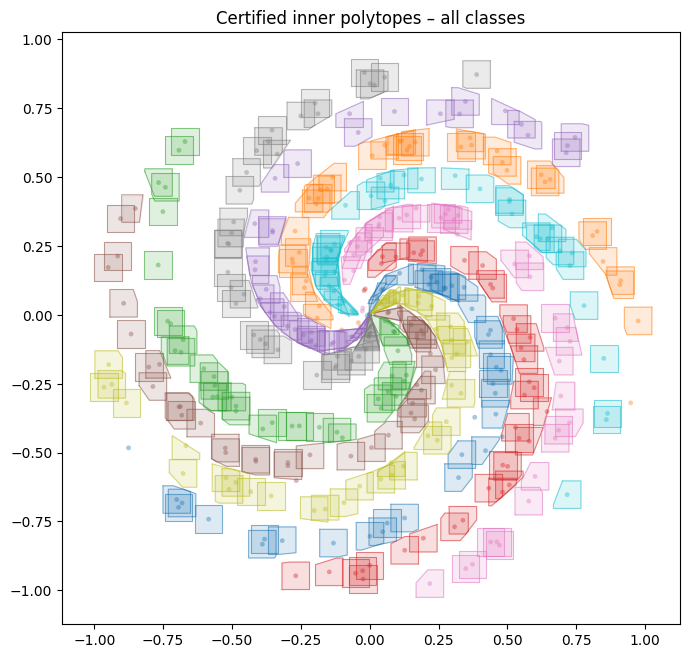

In [21]:
CMAP = plt.cm.get_cmap('tab10', n_classes)

fig, ax = plt.subplots(figsize=(7, 7))

for label in range(n_classes):
    bd    = all_bounds[label]
    color = CMAP(label)

    ax.scatter(bd['X'][:, 0], bd['X'][:, 1],
               s=12, alpha=0.4, color=color, edgecolors='none')

    for i in range(bd['lA'].shape[0]):
        poly = make_polygon(bd['lA'][i], bd['lbias'][i], bd['X'][i], EPS)
        if poly is None:
            continue
        xs, ys = poly.exterior.xy
        ax.fill(xs, ys, alpha=0.15, color=color)
        ax.plot(xs, ys, lw=0.7, alpha=0.5, color=color)

ax.set_aspect('equal')
ax.set_title('Certified inner polytopes – all classes')
plt.tight_layout()
plt.show()

## 7 – Per-class union of polytopes

`shapely.ops.unary_union` merges overlapping/adjacent polytopes within the
same class into a single geometry.

In [22]:
def build_class_union(label, bounds, eps):
    """Union of all certified polytopes for one class."""
    bd    = bounds[label]
    polys = []
    for i in range(bd['lA'].shape[0]):
        p = make_polygon(bd['lA'][i], bd['lbias'][i], bd['X'][i], eps)
        if p is not None:
            polys.append(p)
    return unary_union(polys) if polys else Polygon()


class_unions = {}
for label in range(n_classes):
    class_unions[label] = build_class_union(label, all_bounds, EPS)
    print(f'  class {label}: union area = {class_unions[label].area:.6f}')

  class 0: union area = 0.178973
  class 1: union area = 0.172574
  class 2: union area = 0.184641
  class 3: union area = 0.197719
  class 4: union area = 0.161501
  class 5: union area = 0.197691
  class 6: union area = 0.175487
  class 7: union area = 0.186479
  class 8: union area = 0.187475
  class 9: union area = 0.166773


## 8 – Overlap removal (priority-based refinement)

Even after clipping to the $\varepsilon$-ball, polytopes from **different**
classes can still overlap (the linear relaxation is an approximation).
We resolve conflicts by priority: label 0 keeps its full region, label 1
has the label-0 footprint subtracted, and so on.

$$U'_y = U_y \setminus \bigcup_{y' < y} U_{y'}$$

Pass a custom `priority_order` list to change the ranking.

In [23]:
def refine_unions_by_priority(unions, priority_order=None):
    """
    Subtract higher-priority class regions from lower-priority ones.

    Parameters
    ----------
    unions         : dict[int, Polygon|MultiPolygon]
    priority_order : list[int] or None – highest priority first.

    Returns
    -------
    refined : dict[int, Polygon|MultiPolygon]
    """
    if priority_order is None:
        priority_order = sorted(unions.keys())

    refined = {}
    placed  = Polygon()   # accumulator of all previously placed regions

    for label in priority_order:
        region = unions[label]
        if region.is_empty:
            refined[label] = region
            continue

        refined[label] = region.difference(placed)
        placed          = placed.union(region)   # use original footprint

    return refined


refined_unions = refine_unions_by_priority(class_unions)

print('Refined areas:')
for label in range(n_classes):
    raw = class_unions[label].area
    ref = refined_unions[label].area
    print(f'  class {label}: {raw:.6f} → {ref:.6f}  (removed {raw-ref:.6f})')

Refined areas:
  class 0: 0.178973 → 0.178973  (removed -0.000000)
  class 1: 0.172574 → 0.172574  (removed -0.000000)
  class 2: 0.184641 → 0.184641  (removed 0.000000)
  class 3: 0.197719 → 0.197668  (removed 0.000051)
  class 4: 0.161501 → 0.161491  (removed 0.000009)
  class 5: 0.197691 → 0.197642  (removed 0.000049)
  class 6: 0.175487 → 0.175458  (removed 0.000030)
  class 7: 0.186479 → 0.186462  (removed 0.000017)
  class 8: 0.187475 → 0.187475  (removed 0.000000)
  class 9: 0.166773 → 0.166772  (removed 0.000000)


## 9 – Visualisation: raw union vs refined

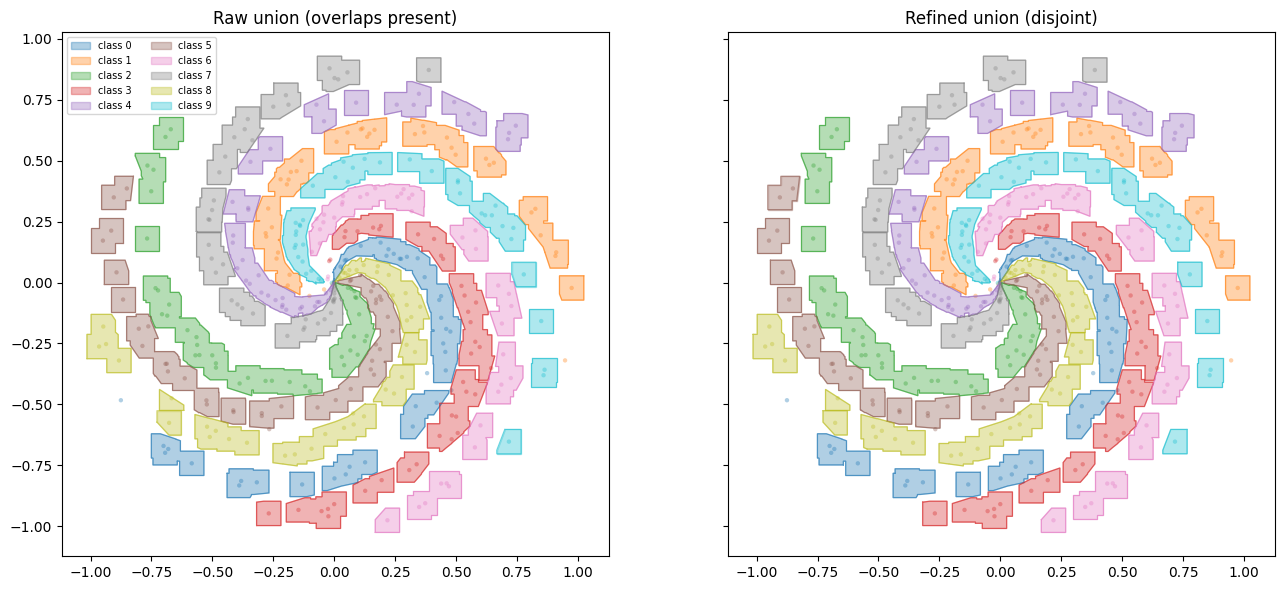

In [24]:
def plot_geom(ax, geom, color, alpha=0.35, label=None):
    """Plot a Polygon or MultiPolygon."""
    geoms = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
    for i, g in enumerate(geoms):
        if g.is_empty or g.area < 1e-14:
            continue
        xs, ys = g.exterior.xy
        ax.fill(xs, ys, alpha=alpha, color=color,
                label=label if i == 0 else None)
        ax.plot(xs, ys, lw=0.8, color=color, alpha=0.6)


fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, title, unions in [
        (axes[0], 'Raw union (overlaps present)',  class_unions),
        (axes[1], 'Refined union (disjoint)',      refined_unions)]:

    for label in range(n_classes):
        ax.scatter(all_bounds[label]['X'][:, 0],
                   all_bounds[label]['X'][:, 1],
                   s=10, alpha=0.35, color=CMAP(label), edgecolors='none')
        plot_geom(ax, unions[label], color=CMAP(label), label=f'class {label}')

    ax.set_aspect('equal')
    ax.set_title(title)

axes[0].legend(loc='upper left', fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## 10 – Pairwise overlap heatmap (before refinement)

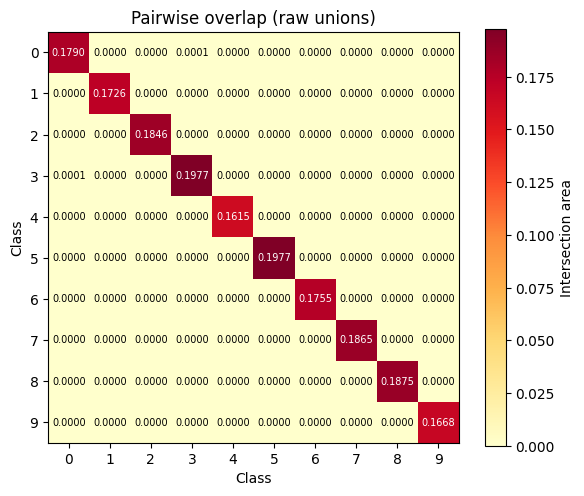

In [25]:
overlap = np.zeros((n_classes, n_classes))
for i in range(n_classes):
    for j in range(i, n_classes):
        area = class_unions[i].intersection(class_unions[j]).area
        overlap[i, j] = area
        overlap[j, i] = area

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(overlap, cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Intersection area')
ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xlabel('Class')
ax.set_ylabel('Class')
ax.set_title('Pairwise overlap (raw unions)')

for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, f'{overlap[i,j]:.4f}',
                ha='center', va='center', fontsize=7,
                color='white' if overlap[i,j] > overlap.max()*0.6 else 'black')

plt.tight_layout()
plt.show()